# ================================================
# K-Nearest Neighbor Classification Mini Project
# ===============================================

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# Set style for plotting
sns.set_theme(style="whitegrid")

## ==========================================
## 1. Load and Explore Dataset
## ==========================================

In [3]:
print("--- Step 1: Loading and Exploring Data ---")
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Dataset Shape: {X.shape}")
print(f"Target Distribution:\n{y.value_counts(normalize=True)}")
# Note: 0 = Malignant, 1 = Benign

--- Step 1: Loading and Exploring Data ---
Dataset Shape: (569, 30)
Target Distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


## ==========================================
## 2. Handle Missing Values & Visualize
## ==========================================

In [5]:
print("\n--- Step 2: Checking for Missing Values ---")
print(f"Total missing values: {X.isnull().sum().sum()}")


--- Step 2: Checking for Missing Values ---
Total missing values: 0


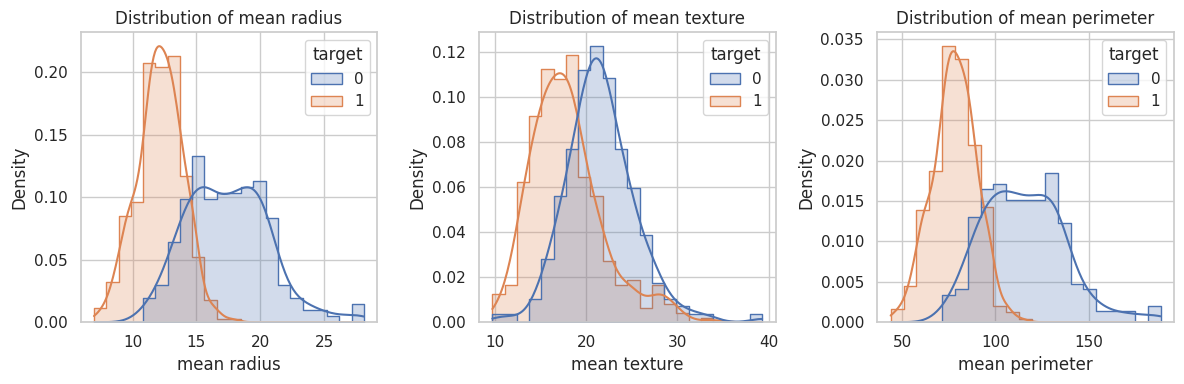

In [6]:
# Visualize distributions of the first few features
plt.figure(figsize=(12, 4))
for i, feature in enumerate(data.feature_names[:3]):
    plt.subplot(1, 3, i+1)
    sns.histplot(data=X, x=feature, hue=y, kde=True, element="step", stat="density", common_norm=False)
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()

## ==========================================
## 3. Split Data into Train/Test Sets
# ==========================================
## 80/20 split with stratify to maintain class proportions

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (455, 30)
Testing set shape: (114, 30)


## ==========================================
## 4. Feature Scaling
## ==========================================
## Standardizing features (mean=0, variance=1)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Fit ONLY on training data to prevent leakage

## ==========================================
## 5 & 6. Cross-Validation for Optimal K
## ==========================================

In [9]:
print("\n--- Step 5 & 6: Hyperparameter Tuning via Cross-Validation ---")
k_values = [1, 3, 5, 7, 9, 11]
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-Fold Cross Validation
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"k = {k} | 5-Fold CV Accuracy: {scores.mean():.4f}")


--- Step 5 & 6: Hyperparameter Tuning via Cross-Validation ---
k = 1 | 5-Fold CV Accuracy: 0.9451
k = 3 | 5-Fold CV Accuracy: 0.9692
k = 5 | 5-Fold CV Accuracy: 0.9670
k = 7 | 5-Fold CV Accuracy: 0.9692
k = 9 | 5-Fold CV Accuracy: 0.9692
k = 11 | 5-Fold CV Accuracy: 0.9626


## ==========================================
## 7. Plot k vs. Accuracy
## ==========================================

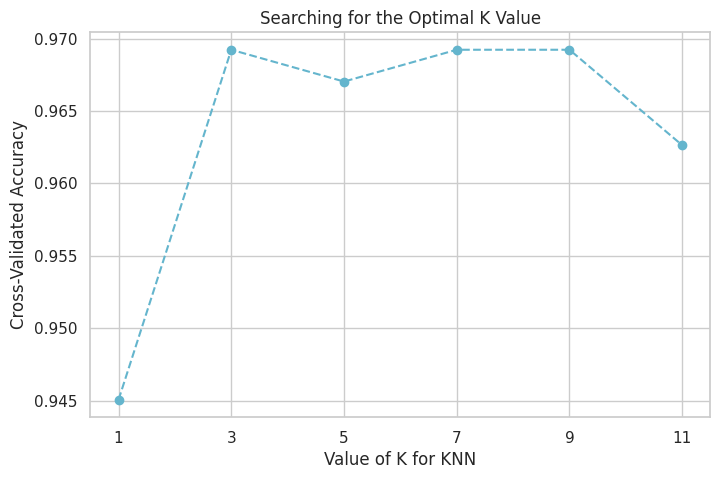

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='--', color='c')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Searching for the Optimal K Value')
plt.xticks(k_values)
plt.show()

In [11]:
# Identify optimal k
optimal_k = k_values[np.argmax(cv_scores)]
print(f"\nOptimal K identified: {optimal_k}")


Optimal K identified: 3


## ==========================================
## 8. Train & Evaluate Final Model
## ==========================================

In [16]:
print(f"\n--- Step 8: Evaluating Final Model (k={optimal_k}) ---")
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)


--- Step 8: Evaluating Final Model (k=3) ---


KNeighborsClassifier(n_neighbors=3)

In [17]:
# Predictions
y_pred = final_knn.predict(X_test_scaled)

In [18]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [19]:
print(f"Final Model Accuracy:  {accuracy:.4f}")
print(f"Final Model Precision: {precision:.4f}")
print(f"Final Model Recall:    {recall:.4f}")
print(f"Final Model F1-Score:  {f1:.4f}")

Final Model Accuracy:  0.9825
Final Model Precision: 0.9730
Final Model Recall:    1.0000
Final Model F1-Score:  0.9863


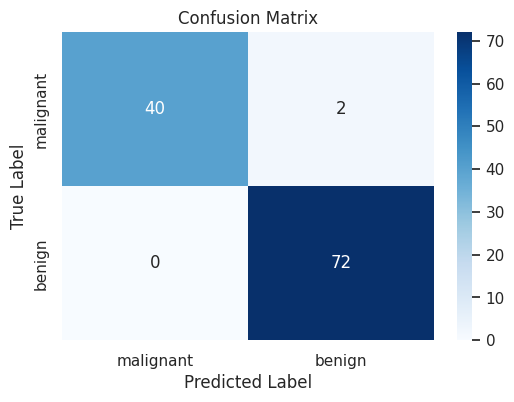

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## ==========================================
## 9. Test Predictions on New Sample Data
## ==========================================

In [21]:
print("\n--- Step 9: Testing on a Synthetic New Sample ---")
# Create a fake sample by taking the mean values of the dataset and tweaking them
new_sample = X.mean().values.reshape(1, -1)

# CRITICAL STEP: Scale the new sample using the existing fitted scaler
new_sample_scaled = scaler.transform(new_sample)

prediction = final_knn.predict(new_sample_scaled)
prediction_proba = final_knn.predict_proba(new_sample_scaled)

print(f"New Sample Prediction: {data.target_names[prediction[0]]}")
print(f"Prediction Probability (Malignant vs Benign): {prediction_proba[0]}")


--- Step 9: Testing on a Synthetic New Sample ---
New Sample Prediction: malignant
Prediction Probability (Malignant vs Benign): [0.66666667 0.33333333]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
